In [1]:
import numpy as np
import math
from matplotlib import pyplot as plt
import random
import pickle
import os
import sys

In [2]:
current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

# Import pickle operations

from pickle_file_operations import read_pickle, write_pickle
from optimization_dataclasses import Optimization_Results
# pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
def my_func(x, y, a, b):
    z = (-1 * b) ** -1 * x * ((np.log((y / x) - 1)) - a)
    z_positive = max(z, 0)
    return round(z_positive, 3)

def min_max_scale(min_X, max_X, X):
    return [(x - min_X) / (max_X - min_X) for x in X]

def inv_min_max_scale(min_X, max_X, scaled_X):
    return [x * (max_X - min_X) + min_X for x in scaled_X]

def generate_training_data(num_points):

    input_data = []
    output_data = []
    random.seed(12)
    for point in range(num_points):
        a = round(random.uniform(4, 8), 3)
        b = round(random.uniform(0.25, 2) , 3)
        y = round(random.uniform(0.1, 20) , 3)
        x = round(random.uniform(0.1 * 0.98, 0.98 * y) , 3)
        input_data.append([x, y, a, b])
        output_data.append([my_func(x, y, a, b)])

    return np.array(input_data), np.array(output_data)
def read_pickle(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

In [4]:
num_points = 300000
input_data, output_data = generate_training_data(num_points)

In [5]:
var_name = ["x", "y", "a", "b"]
min_max_scale_dict = {var_name[i]: {"min": min(input_data.transpose()[i]), "max": max(input_data.transpose()[i])} for i in range(4)}

# Proper minmax scaler
min_max_scale_dict["z"] = {"min": min(output_data)[0], "max": max(output_data)[0]}


In [6]:
# Scale the data

scaled_input_data = np.array([min_max_scale(min_max_scale_dict[var_name[i]]["min"], 
                                            min_max_scale_dict[var_name[i]]["max"], input_data.transpose()[i])
                              for i in range(4)
                             ]
                            ).transpose()
scaled_output_data = np.array(min_max_scale(min_max_scale_dict["z"]["min"], 
                                            min_max_scale_dict["z"]["max"], output_data.transpose())).transpose()

In [7]:
import tensorflow as tf

In [9]:
# Get NN models
nn_path = os.path.join(cwd, "NN models")
unn_model = tf.keras.models.load_model(os.path.join(nn_path, "Unconstrained model", "Base_NN.keras"))
cnn_model = tf.keras.models.load_model(os.path.join(nn_path, "Constrained model", "Base_NN.keras"))
ficnn_model = tf.keras.models.load_model(os.path.join(nn_path, "FICNN model", "Base_FICNN.keras"))


In [10]:
import pandas as pd
from pandas.api.types import CategoricalDtype

In [11]:
unn_pred_output = unn_model.predict(scaled_input_data)
cnn_pred_output = cnn_model.predict(scaled_input_data)
ficnn_pred_output = ficnn_model.predict(scaled_input_data)
nn_df = pd.DataFrame({"Output_value": scaled_output_data.flatten(), "UNN output": unn_pred_output.flatten(), 
                      "CNN output": cnn_pred_output.flatten(), "FICNN output": ficnn_pred_output.flatten()})
unn_rmse = np.sqrt(np.mean((nn_df['Output_value'] - nn_df['UNN output']) ** 2)) * 741.868
cnn_rmse = np.sqrt(np.mean((nn_df['Output_value'] - nn_df['CNN output']) ** 2)) * 741.868
ficnn_rmse = np.sqrt(np.mean((nn_df['Output_value'] - nn_df['FICNN output']) ** 2)) * 741.868


9375/9375 ━━━━━━━━━━━━━━━━━━━━ 6s 651us/step
9375/9375 ━━━━━━━━━━━━━━━━━━━━ 6s 652us/step
9375/9375 ━━━━━━━━━━━━━━━━━━━━ 7s 695us/step


In [14]:
rmse_dict = {"PWL": -1000, "Gurobi ML": unn_rmse, "PCAR": unn_rmse, "PCTAR": unn_rmse, "NWLP": cnn_rmse, "FICNN": ficnn_rmse}

In [15]:
summary_tables = read_pickle("summmary_tables.pickle")
summary_tables.methodology.unique()

array(['PWL', 'Gurobi ML', 'NWLP', 'FICNN', 'PCAR', 'PCTAR'], dtype=object)

In [16]:
def get_expected_rmse(row):
    method = row['methodology']
    return rmse_dict[method]

In [17]:
rmse_table = (summary_tables.groupby(["scenario_type", "methodology"])["mean_square_error"].mean()) **0.5
rmse_table = rmse_table.reset_index()
rmse_table["expected_rmse"] = rmse_table.apply(get_expected_rmse, axis = 1)

In [18]:
category_order = CategoricalDtype(categories=["High_prices", "Med_prices", "Low_prices"], ordered=True)
rmse_table["scenario_type"]=rmse_table["scenario_type"].astype(category_order)
rmse_table = rmse_table.sort_values(by="scenario_type")
rmse_table

,scenario_type,methodology,mean_square_error,expected_rmse
0,High_prices,FICNN,11.431782,6.584968
1,High_prices,Gurobi ML,105.188984,1.598535
2,High_prices,NWLP,11.445783,6.574103
3,High_prices,PCAR,89.276783,1.598535
4,High_prices,PCTAR,89.276783,1.598535
5,High_prices,PWL,1.518822,-1000.000000
15,Med_prices,PCAR,41.171942,1.598535
14,Med_prices,NWLP,8.760128,6.574103
13,Med_prices,Gurobi ML,40.517644,1.598535
12,Med_prices,FICNN,7.560678,6.584968


In [ ]:
rmse_table[]

In [23]:
colors = ['xkcd:green', 'xkcd:purple', 'xkcd:orange', 'xkcd:blue', 'xkcd:red', "xkcd:dark gray"]
plot_order = ["PWL", "Gurobi ML", "PCTAR", "PCAR", 
              # "NWLP", 
              "FICNN"]

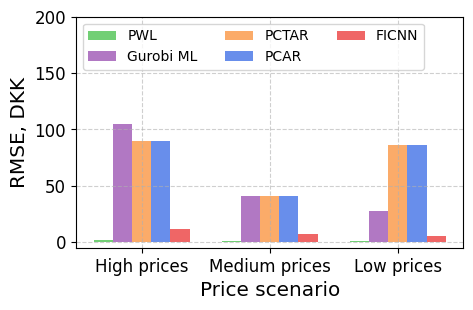

In [24]:
# Plotting
plt.figure(figsize=(5, 3))

# Set bar width and position
bar_width = 0.15
x_positions = np.arange(len(rmse_table['scenario_type'].unique()))
handles = []
# Create separate bars for each methodology
for i, methodology in enumerate(plot_order):
    
    if methodology == "Proposed":
        color_dot = "green"
    else:
        color_dot = "blue"
    subset = rmse_table[rmse_table['methodology'] == methodology]
    bar_positions = x_positions + ((i - 1.5) * bar_width)  # Shift bars for each methodology
    bars = plt.bar(bar_positions, subset['mean_square_error'], width=bar_width, label=methodology, alpha=0.6, zorder=1, color=colors[i])
    handles.append(bars)

    # # Annotate expected RMSE values on top of each bar as dots
    # for bar, expected_rmse in zip(bars, subset['expected_rmse']):
    #     yval = bar.get_height()
    #     plt.scatter(bar.get_x() + bar.get_width() / 2, expected_rmse, color=color_dot, s=50, zorder=5)  # Red dots above bars
# Adding labels and title
plt.xlabel('Price scenario', fontsize="x-large")
plt.ylabel('RMSE, DKK', fontsize="x-large")
plt.xticks(x_positions + bar_width / 2, ["High prices", "Medium prices", "Low prices"], fontsize="large")  # Center the x-ticks
plt.yticks(fontsize="large")
plt.ylim([-5, 200])

# # Add a custom legend for expected RMSE levels
# expected_rmse_patch_1 = plt.Line2D([0], [0], marker='o', color='w', label='UC training RMSE',
#                                    markerfacecolor='blue', markersize=8)
# handles.append(expected_rmse_patch_1)
# expected_rmse_patch_2 = plt.Line2D([0], [0], marker='o', color='w', label='NNW training RMSE',
#                                    markerfacecolor='green', markersize=8)
# handles.append(expected_rmse_patch_2)
plt.legend(ncols=3, handles = handles, loc="upper left", fontsize="medium")
plt.grid(axis='both', linestyle='--', alpha=0.6, zorder=0)
plt.savefig(os.path.join(cwd, "images", "rmse_plot.pdf"), bbox_inches="tight")
plt.show()

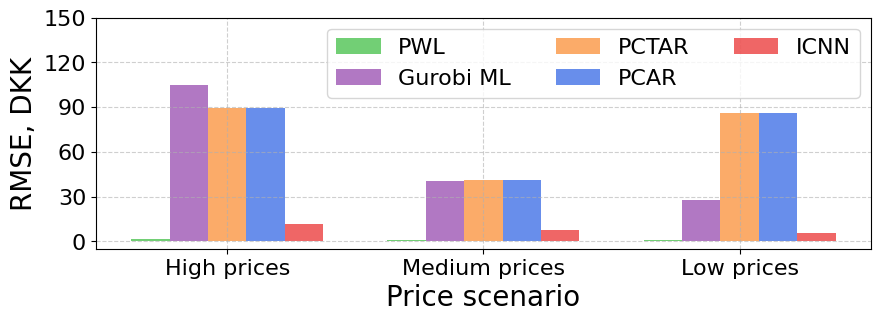

In [25]:
# Plotting
plt.figure(figsize=(10, 3))

# Set bar width and position
bar_width = 0.15
x_positions = np.arange(len(rmse_table['scenario_type'].unique()))
handles = []
# Create separate bars for each methodology
for i, methodology in enumerate(plot_order):
    if methodology == "FICNN":
        new_label = "ICNN"
    # elif methodology == "NWLP":
    #     new_label = "ICNN 1"
    else:
        new_label = methodology
    if methodology == "Proposed":
        color_dot = "green"
    else:
        color_dot = "blue"
    subset = rmse_table[rmse_table['methodology'] == methodology]
    bar_positions = x_positions + ((i - 1.5) * bar_width)  # Shift bars for each methodology
    bars = plt.bar(bar_positions, subset['mean_square_error'], width=bar_width, label=new_label, alpha=0.6, zorder=1, color=colors[i])
    handles.append(bars)

    # # Annotate expected RMSE values on top of each bar as dots
    # for bar, expected_rmse in zip(bars, subset['expected_rmse']):
    #     yval = bar.get_height()
    #     plt.scatter(bar.get_x() + bar.get_width() / 2, expected_rmse, color=color_dot, s=50, zorder=5)  # Red dots above bars
# Adding labels and title
plt.xlabel('Price scenario', fontsize=20)
plt.ylabel('RMSE, DKK', fontsize=20)
plt.xticks(x_positions + bar_width / 2, ["High prices", "Medium prices", "Low prices"], fontsize=16)  # Center the x-ticks
plt.yticks([30 * i for i in range(6)], fontsize=16)
plt.ylim([-5, 150])

# # Add a custom legend for expected RMSE levels
# expected_rmse_patch_1 = plt.Line2D([0], [0], marker='o', color='w', label='UC training RMSE',
#                                    markerfacecolor='blue', markersize=8)
# handles.append(expected_rmse_patch_1)
# expected_rmse_patch_2 = plt.Line2D([0], [0], marker='o', color='w', label='NNW training RMSE',
#                                    markerfacecolor='green', markersize=8)
# handles.append(expected_rmse_patch_2)
plt.legend(ncols=3, handles = handles, loc="upper right", fontsize=16)
plt.grid(axis='both', linestyle='--', alpha=0.6, zorder=0)
plt.savefig(os.path.join(cwd, "images", "rmse_plot_v2.pdf"), bbox_inches="tight")
plt.show()